# Week 6 Final Submission
## Building and Evaluating Baseline Models for Emergency Department Triage

**Student:** Shari Oliver

**Programme:** CariSurg MedTech Pathways

**Dataset:** `yaleemmlc_admissionprediction_triage.csv`

---

## Objective

The objective of this notebook is to develop and evaluate two interpretable baseline machine learning models for Emergency Department (ED) triage prediction using the Emergency Severity Index (ESI). A logistic regression classifier and a decision tree classifier are compared against a stratified random baseline to determine whether they provide clinically meaningful predictive performance.

Both models are evaluated using an 80/20 stratified train-test split and assessed using accuracy, precision, recall and F1-score for each ESI level. Particular attention is given to identifying ESI Level 1 patients because failing to recognise these critically ill patients may delay life-saving treatment.

This notebook follows reproducible machine learning practices using a fixed random seed and documents each modelling step for transparency.

## 1. Import Libraries and Configure the Environment

This section imports all required libraries and sets a fixed random seed to ensure that results are reproducible.

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)

warnings.filterwarnings("ignore")

RANDOM_SEED = 42

print("Random Seed =", RANDOM_SEED)

Random Seed = 42


## 2. Create Output Folders

Generated figures and summary tables are saved into organised folders so they can be added directly to the GitHub repository.

In [3]:
OUTPUT_DIR = Path("week6_outputs")

PLOT_DIR = OUTPUT_DIR / "plots"
DOC_DIR = OUTPUT_DIR / "docs"

PLOT_DIR.mkdir(parents=True, exist_ok=True)
DOC_DIR.mkdir(parents=True, exist_ok=True)

print("Plots:", PLOT_DIR)
print("Documents:", DOC_DIR)

Plots: week6_outputs/plots
Documents: week6_outputs/docs


## 3. Load the Dataset

The programme-provided Emergency Department triage dataset is loaded from a local file. The raw dataset is **not committed to GitHub** because it contains programme-controlled data.

The notebook checks several common file locations (including Google Colab and Google Drive) before loading the dataset.

In [4]:
DATASET_NAME = "yaleemmlc_admissionprediction_triage.csv"

possible_paths = [
    Path(DATASET_NAME),
    Path("/content") / DATASET_NAME,
    Path("/content/drive/MyDrive") / DATASET_NAME,
    Path("/content/drive/MyDrive/CariSurg") / DATASET_NAME,
]

DATA_PATH = None

for path in possible_paths:
    if path.exists():
        DATA_PATH = path
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        f"Could not locate '{DATASET_NAME}'. "
        "Please upload the dataset or update the file path."
    )

df = pd.read_csv(DATA_PATH, index_col=0)

print("Dataset loaded successfully!")
print(f"Dataset location: {DATA_PATH}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

df.head()

Dataset loaded successfully!
Dataset location: yaleemmlc_admissionprediction_triage.csv
Rows: 55,121
Columns: 225


,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,Disabled,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,Full Time,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,Full Time,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,Not Employed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4. Dataset Overview

Before building any machine learning model, it is important to understand the structure of the dataset.

The following checks summarise:

- dataset dimensions;
- variable types;
- missing values;
- the Emergency Severity Index (ESI) class distribution.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55121 entries, 7 to 433332
Columns: 225 entries, dep_name to cc_wristpain
dtypes: float64(210), object(15)
memory usage: 95.0+ MB


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
dep_name,55121,3,A,34933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
esi,55121.0,NaN,NaN,NaN,2.87747,0.751829,1.0,2.0,3.0,3.0,5.0
age,55121.0,NaN,NaN,NaN,55.31547,19.544287,18.0,40.0,55.0,70.0,107.0
gender,55121,2,Female,31744,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ethnicity,55121,4,Non-Hispanic,45142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
cc_woundcheck,55121.0,NaN,NaN,NaN,0.005424,0.073451,0.0,0.0,0.0,0.0,1.0
cc_woundinfection,55121.0,NaN,NaN,NaN,0.004209,0.06474,0.0,0.0,0.0,0.0,1.0
cc_woundre-evaluation,55121.0,NaN,NaN,NaN,0.001814,0.042555,0.0,0.0,0.0,0.0,1.0
cc_wristinjury,55121.0,NaN,NaN,NaN,0.000562,0.023709,0.0,0.0,0.0,0.0,1.0


## 5. Define the Prediction Target

The target variable is the Emergency Severity Index (ESI), which represents the patient's triage priority on arrival.

This notebook supports either naming convention used in previous programme datasets.

In [7]:
possible_targets = [
    "esi",
    "Triage_Level",
    "triage_level"
]

TARGET = None

for col in possible_targets:
    if col in df.columns:
        TARGET = col
        break

if TARGET is None:
    raise ValueError(
        f"Target column not found. Expected one of: {possible_targets}"
    )

print("Target variable:", TARGET)

Target variable: esi


## 6. Explore the Target Distribution

Understanding the class distribution is essential before training any model.

Emergency Department triage datasets are naturally imbalanced because critically ill (ESI Level 1) patients are far less common than lower-acuity patients. This imbalance influences both model training and model evaluation.

In [8]:
esi_summary = (
    df[TARGET]
    .value_counts()
    .sort_index()
    .rename_axis("ESI Level")
    .reset_index(name="Count")
)

esi_summary["Percentage"] = (
    esi_summary["Count"] /
    esi_summary["Count"].sum()
    *100
).round(2)

display(esi_summary)

,ESI Level,Count,Percentage
0,1.0,77,0.14
1,2.0,17924,32.52
2,3.0,27010,49.00
3,4.0,8896,16.14
4,5.0,1214,2.20


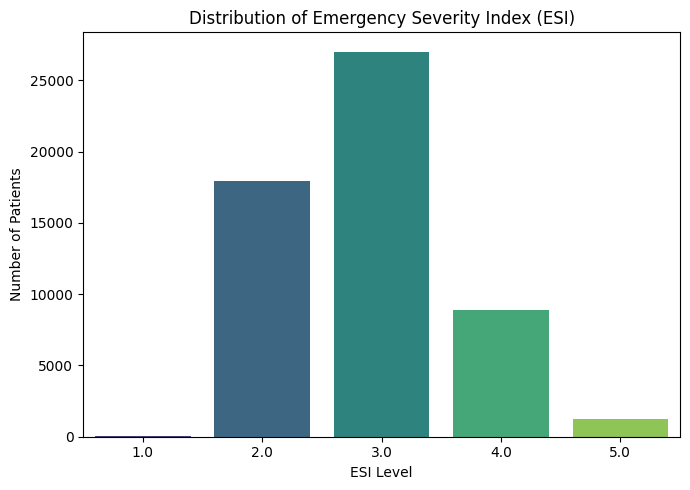

In [9]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x=TARGET,
    palette="viridis"
)

plt.title("Distribution of Emergency Severity Index (ESI)")
plt.xlabel("ESI Level")
plt.ylabel("Number of Patients")

plt.tight_layout()

plt.savefig(
    PLOT_DIR/"SOliver_Week6_ESI_Distribution.png",
    dpi=300
)

plt.show()

### Interpretation

The ESI distribution is noticeably imbalanced, with substantially fewer patients in the highest-acuity category (ESI Level 1) than in the lower-acuity groups.

Because of this imbalance, overall accuracy alone is not an appropriate measure of model performance. Additional evaluation metrics that consider performance across all classes will be required.

## 7. Feature Selection and Leakage Assessment

The objective of this baseline model is to predict the patient's Emergency Severity Index (ESI) using information that is realistically available at the time of triage.

Only variables that would typically be known when the patient first arrives are considered appropriate predictors. Variables generated later in the patient's hospital journey are excluded because they would not be available when the triage decision is made.

Using future information to predict an earlier event is known as **data leakage**. Leakage can produce unrealistically high model performance that would not generalise to real clinical practice.

For this baseline model:

- Vital signs are included because they are measured during triage.
- Age is included because it is immediately available.
- Arrival mode is included because it is recorded on presentation.
- Chief complaint indicators are included because they represent the patient's presenting problem.
- Race, ethnicity and insurance status are intentionally excluded from modelling. These variables may later be used for fairness auditing but are not used as predictors in this baseline.
- Hospital outcomes, admission information and disposition variables are excluded because they occur after triage.

In [10]:
# -----------------------------
# Define target variable
# -----------------------------

TARGET = "esi"

# -----------------------------
# Candidate feature groups
# -----------------------------

vital_features = [
    col for col in df.columns
    if any(term in col.lower() for term in
           ["hr","sbp","dbp","rr","o2","temp","glucose"])
]

arrival_features = [
    col for col in df.columns
    if "arrival" in col.lower()
]

chief_complaint_features = [
    col for col in df.columns
    if col.lower().startswith("cc_")
]

demographic_features = [
    col for col in ["age"]
    if col in df.columns
]

# Build final predictor list

selected_features = (
    demographic_features +
    vital_features +
    arrival_features +
    chief_complaint_features
)

selected_features = list(dict.fromkeys(selected_features))

print("Number of selected features:", len(selected_features))
print(selected_features[:20])

Number of selected features: 213
['age', 'arrivalmode', 'arrivalmonth', 'arrivalday', 'arrivalhour_bin', 'triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp', 'triage_vital_rr', 'triage_vital_o2', 'triage_vital_o2_device', 'triage_vital_temp', 'triage_glucose', 'cc_blurredvision', 'cc_cardiacarrest', 'cc_diarrhea', 'cc_headache-recurrentorknowndxmigraines', 'cc_irregularheartbeat', 'cc_skinirritation', 'cc_sorethroat']


### Checking for Possible Data Leakage

The following search identifies variables that appear to contain post-triage information. These variables should **not** be used for model training because they would not be known when assigning the patient's ESI level.

In [11]:
leakage_keywords = [
    "admit",
    "admission",
    "disposition",
    "hospital",
    "los",
    "outcome",
    "death",
    "mortality",
    "icu"
]

possible_leakage = []

for col in df.columns:
    if any(word in col.lower() for word in leakage_keywords):
        possible_leakage.append(col)

print("Potential leakage variables:")
possible_leakage

Potential leakage variables:


['disposition', 'cc_breathingdifficulty', 'cc_lossofconsciousness']

### Interpretation

The selected predictor variables represent information that would generally be available at the point of triage and are therefore appropriate for a baseline prediction model.

Potential post-triage variables were identified separately and deliberately excluded from the predictor set to avoid data leakage. This ensures that model performance more accurately reflects how the model would behave if deployed in a real emergency department.

## 8. Create the Modelling Dataset

The modelling dataset is created using the selected predictor variables and the ESI target variable.

Rows with missing ESI values are removed because the model requires a known outcome for supervised learning. Missing predictor values are retained and will be handled during preprocessing after the train-test split to prevent data leakage.

In [12]:
model_df = df[selected_features + [TARGET]].copy()

# Remove rows with missing target values
model_df = model_df.dropna(subset=[TARGET])

# Ensure target is numeric
model_df[TARGET] = pd.to_numeric(
    model_df[TARGET],
    errors="coerce"
)

model_df = model_df.dropna(subset=[TARGET])

model_df[TARGET] = model_df[TARGET].astype(int)

X = model_df[selected_features]
y = model_df[TARGET]

print("Predictor matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Predictor matrix shape: (55121, 213)
Target vector shape: (55121,)


In [13]:
print("Predictor data types")

display(
    X.dtypes.value_counts()
)

Predictor data types


,count
float64,209
object,4


## 9. Split the Dataset into Training and Testing Sets

The dataset is divided into **80% training data** and **20% testing data**.

A **stratified split** is used so that the proportion of each Emergency Severity Index (ESI) class remains approximately the same in both datasets. This is particularly important because ESI Level 1 patients are relatively uncommon.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_SEED
)

print("Training observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])

Training observations: 44096
Testing observations: 11025


In [15]:
split_summary = pd.DataFrame({
    "Full Dataset": y.value_counts(normalize=True).sort_index(),
    "Training Set": y_train.value_counts(normalize=True).sort_index(),
    "Testing Set": y_test.value_counts(normalize=True).sort_index()
})

display(split_summary.round(3))

,Full Dataset,Training Set,Testing Set
esi,,,
1,0.001,0.001,0.001
2,0.325,0.325,0.325
3,0.490,0.490,0.490
4,0.161,0.161,0.161
5,0.022,0.022,0.022


### Interpretation

The class proportions are very similar across the full dataset, training set and testing set. This confirms that stratification successfully preserved the ESI distribution, allowing both datasets to remain representative of the original population.

## 10. Data Preprocessing

The baseline models require missing values to be handled before training.

Numeric variables are imputed using the **median**, which is robust to extreme values often seen in clinical data.

Categorical variables are imputed using the **most frequent category** before one-hot encoding.

For logistic regression, numeric variables are also standardised because the model performs best when predictors are measured on comparable scales.

The decision tree does not require feature scaling.

In [16]:
numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numeric Features:", len(numeric_features))
print("Categorical Features:", len(categorical_features))

Numeric Features: 209
Categorical Features: 4


In [17]:
numeric_pipeline_lr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_pipeline_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [18]:
preprocessor_lr = ColumnTransformer([
    ("numeric", numeric_pipeline_lr, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

preprocessor_tree = ColumnTransformer([
    ("numeric", numeric_pipeline_tree, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

### Interpretation

Separate preprocessing pipelines were created for the logistic regression and decision tree models. Standardisation was applied only to the logistic regression pipeline because tree-based models are not affected by differences in measurement scale.

## 11. Stratified Random Baseline

Before evaluating machine learning models, a simple benchmark is established using a **Dummy Classifier**.

This classifier predicts ESI levels according to their frequency in the training data without learning any clinical relationships.

Both baseline models should perform better than this random benchmark.

In [19]:
dummy_model = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model",
     DummyClassifier(
         strategy="stratified",
         random_state=RANDOM_SEED
     ))
])

dummy_model.fit(X_train, y_train)

dummy_predictions = dummy_model.predict(X_test)

print("Dummy baseline trained successfully.")

Dummy baseline trained successfully.


In [20]:
print(classification_report(
    y_test,
    dummy_predictions,
    zero_division=0
))

              precision    recall  f1-score   support

           1       0.00      0.00      0.00        16
           2       0.33      0.33      0.33      3585
           3       0.49      0.50      0.49      5402
           4       0.15      0.15      0.15      1779
           5       0.05      0.05      0.05       243

    accuracy                           0.38     11025
   macro avg       0.20      0.20      0.20     11025
weighted avg       0.37      0.38      0.37     11025



### Interpretation

The Dummy Classifier provides a minimum performance benchmark. Any clinically useful model should outperform this baseline because it does not use patient information to make predictions.

## 12. Logistic Regression Baseline

Logistic regression is selected as the first baseline because it is a well-established classification algorithm that produces interpretable decision boundaries.

To reduce the effect of class imbalance, the model is trained using **class_weight="balanced"**, allowing less common ESI categories to contribute more during training.

In [21]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor_lr),
    ("model",
     LogisticRegression(
         max_iter=2000,
         class_weight="balanced",
         random_state=RANDOM_SEED
     ))
])

logistic_model.fit(
    X_train,
    y_train
)

logistic_predictions = logistic_model.predict(
    X_test
)

print("Logistic regression trained successfully.")

Logistic regression trained successfully.


In [22]:
print(classification_report(
    y_test,
    logistic_predictions,
    zero_division=0
))

              precision    recall  f1-score   support

           1       0.02      0.62      0.03        16
           2       0.67      0.62      0.65      3585
           3       0.76      0.54      0.63      5402
           4       0.52      0.65      0.58      1779
           5       0.15      0.67      0.25       243

    accuracy                           0.59     11025
   macro avg       0.42      0.62      0.43     11025
weighted avg       0.68      0.59      0.62     11025



### Interpretation

The logistic regression model serves as the primary linear baseline. Its performance will later be compared with both the Dummy Classifier and the Decision Tree to determine whether a simple linear model is sufficient for this triage prediction task.

## 13. Decision Tree Baseline

A decision tree is used as the second baseline model because it can capture non-linear relationships between clinical variables while remaining relatively easy to explain.

The tree depth is limited to `max_depth=5`. This prevents the model from becoming overly complex and memorising noise in the training data. A bounded tree is also easier to interpret and defend clinically.

In [23]:
decision_tree_model = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model",
     DecisionTreeClassifier(
         max_depth=5,
         class_weight="balanced",
         random_state=RANDOM_SEED
     ))
])

decision_tree_model.fit(
    X_train,
    y_train
)

tree_predictions = decision_tree_model.predict(
    X_test
)

print("Decision tree trained successfully.")

Decision tree trained successfully.


In [24]:
print(classification_report(
    y_test,
    tree_predictions,
    zero_division=0
))

              precision    recall  f1-score   support

           1       0.01      0.56      0.03        16
           2       0.50      0.48      0.49      3585
           3       0.85      0.15      0.26      5402
           4       0.00      0.00      0.00      1779
           5       0.04      0.91      0.07       243

    accuracy                           0.25     11025
   macro avg       0.28      0.42      0.17     11025
weighted avg       0.58      0.25      0.29     11025



### Interpretation

The decision tree provides a simple non-linear comparison model. Limiting the tree depth helps reduce overfitting while still allowing the model to identify combinations of vital signs, arrival information and chief complaints that may relate to ESI level.

## 14. Evaluate All Baseline Models

Each model is evaluated using:

- accuracy;
- precision for each ESI class;
- recall for each ESI class;
- F1-score for each ESI class;
- macro F1;
- weighted F1;
- recall for ESI Level 1.

ESI Level 1 recall is reviewed separately because it represents the model's ability to identify the most critically ill patients.

In [25]:
def evaluate_model(model_name, y_true, y_pred):
    """
    Create summary and per-class evaluation tables
    for one classification model.
    """
    report = classification_report(
        y_true,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    summary = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro F1": report["macro avg"]["f1-score"],
        "Weighted F1": report["weighted avg"]["f1-score"],
        "ESI 1 Precision": report.get("1", {}).get("precision", np.nan),
        "ESI 1 Recall": report.get("1", {}).get("recall", np.nan),
        "ESI 1 F1": report.get("1", {}).get("f1-score", np.nan)
    }

    per_class = pd.DataFrame(report).T.reset_index()
    per_class = per_class.rename(
        columns={"index": "Class or Average"}
    )
    per_class.insert(0, "Model", model_name)

    return summary, per_class

In [26]:
model_predictions = {
    "Stratified Random Baseline": dummy_predictions,
    "Logistic Regression": logistic_predictions,
    "Decision Tree": tree_predictions
}

summary_rows = []
per_class_tables = []

for model_name, predictions in model_predictions.items():
    summary, per_class = evaluate_model(
        model_name,
        y_test,
        predictions
    )

    summary_rows.append(summary)
    per_class_tables.append(per_class)

model_comparison = pd.DataFrame(summary_rows).round(3)

per_class_metrics = pd.concat(
    per_class_tables,
    ignore_index=True
).round(3)

display(model_comparison)

,Model,Accuracy,Macro F1,Weighted F1,ESI 1 Precision,ESI 1 Recall,ESI 1 F1
0,Stratified Random Baseline,0.375,0.204,0.375,0.000,0.000,0.000
1,Logistic Regression,0.587,0.427,0.619,0.017,0.625,0.033
2,Decision Tree,0.253,0.169,0.288,0.014,0.562,0.027


In [27]:
display(per_class_metrics)

,Model,Class or Average,precision,recall,f1-score,support
0,Stratified Random Baseline,1,0.000,0.000,0.000,16.000
1,Stratified Random Baseline,2,0.334,0.327,0.331,3585.000
2,Stratified Random Baseline,3,0.491,0.498,0.494,5402.000
3,Stratified Random Baseline,4,0.147,0.148,0.147,1779.000
4,Stratified Random Baseline,5,0.049,0.045,0.047,243.000
5,Stratified Random Baseline,accuracy,0.375,0.375,0.375,0.375
6,Stratified Random Baseline,macro avg,0.204,0.204,0.204,11025.000
7,Stratified Random Baseline,weighted avg,0.374,0.375,0.375,11025.000
8,Logistic Regression,1,0.017,0.625,0.033,16.000
9,Logistic Regression,2,0.674,0.619,0.646,3585.000


In [28]:
model_comparison.to_csv(
    DOC_DIR / "SOliver_Week6_Final_Model_Comparison.csv",
    index=False
)

per_class_metrics.to_csv(
    DOC_DIR / "SOliver_Week6_Final_Per_Class_Metrics.csv",
    index=False
)

print("Evaluation tables saved successfully.")

Evaluation tables saved successfully.


## 15. Compare Model Performance

The comparison plot shows overall accuracy, macro F1, weighted F1 and ESI Level 1 recall for the random baseline, logistic regression and decision tree.

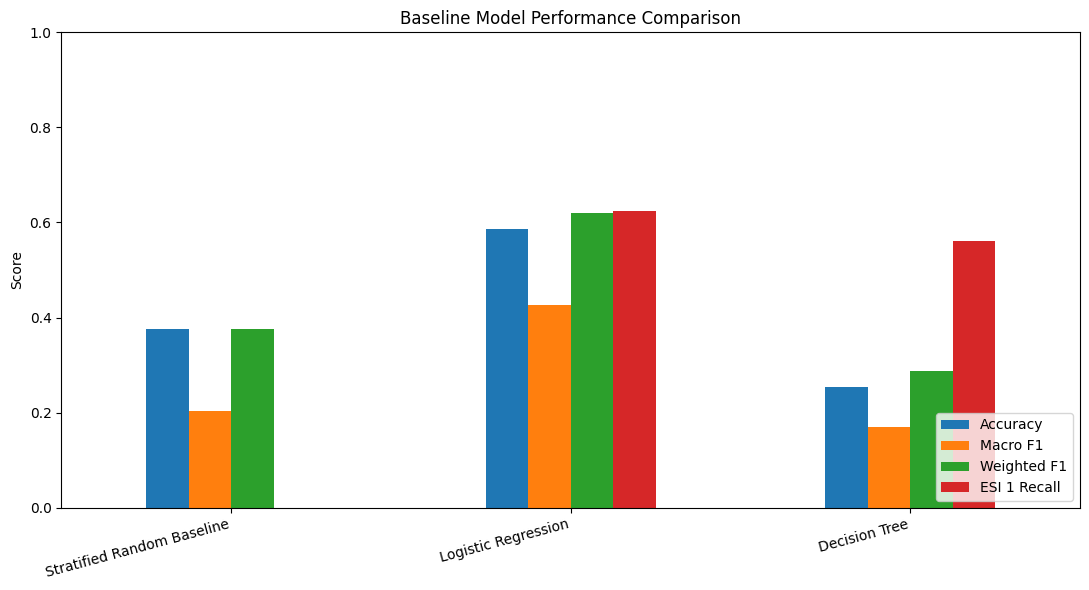

In [29]:
comparison_plot_data = (
    model_comparison
    .set_index("Model")[
        ["Accuracy", "Macro F1", "Weighted F1", "ESI 1 Recall"]
    ]
)

ax = comparison_plot_data.plot(
    kind="bar",
    figsize=(11, 6)
)

ax.set_title("Baseline Model Performance Comparison")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.set_ylim(0, 1)

plt.xticks(
    rotation=15,
    ha="right"
)

plt.legend(
    loc="lower right"
)

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "SOliver_Week6_Final_Model_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

A useful baseline should outperform the stratified random classifier on clinically meaningful measures. The comparison should not be based on accuracy alone. Particular attention should be given to ESI Level 1 recall and macro F1 because both measures are sensitive to performance on less common classes.

## 16. Confusion Matrices

A confusion matrix shows how often each actual ESI level was assigned to each predicted ESI level.

The rows represent the actual ESI level, while the columns represent the predicted ESI level. For ESI Level 1, any count outside the ESI 1-to-ESI 1 cell represents a critically ill patient who was assigned to a less urgent category.

In [30]:
labels = sorted(y_test.unique())

def save_confusion_matrix(
    y_true,
    y_pred,
    title,
    filename
):
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels
    )

    display_matrix = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )

    fig, ax = plt.subplots(
        figsize=(7, 6)
    )

    display_matrix.plot(
        ax=ax,
        cmap="Blues",
        values_format="d",
        colorbar=False
    )

    ax.set_title(title)
    ax.set_xlabel("Predicted ESI Level")
    ax.set_ylabel("Actual ESI Level")

    plt.tight_layout()

    output_path = PLOT_DIR / filename

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved:", output_path)

    return cm

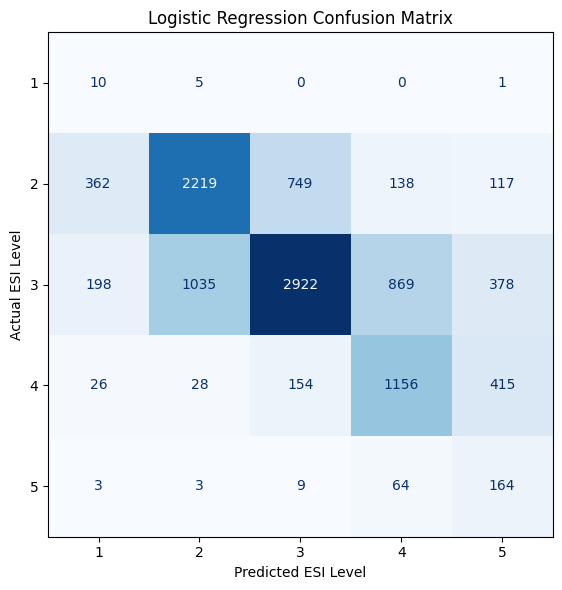

Saved: week6_outputs/plots/SOliver_Week6_Final_Logistic_Regression_Confusion_Matrix.png


In [31]:
logistic_cm = save_confusion_matrix(
    y_test,
    logistic_predictions,
    "Logistic Regression Confusion Matrix",
    "SOliver_Week6_Final_Logistic_Regression_Confusion_Matrix.png"
)

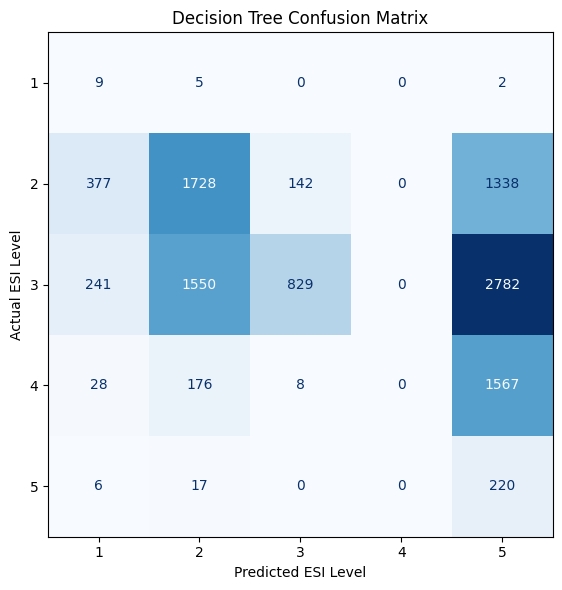

Saved: week6_outputs/plots/SOliver_Week6_Final_Decision_Tree_Confusion_Matrix.png


In [32]:
tree_cm = save_confusion_matrix(
    y_test,
    tree_predictions,
    "Decision Tree Confusion Matrix",
    "SOliver_Week6_Final_Decision_Tree_Confusion_Matrix.png"
)

### Interpretation

The confusion matrices show where each model makes errors across the ESI levels. The most clinically concerning errors occur when actual ESI Level 1 patients are assigned to lower-priority categories. These errors represent under-triage and could delay immediate treatment.

## 17. Macro F1 Versus Weighted F1

Macro F1 calculates the F1-score separately for each ESI class and then gives every class equal importance. This means a rare class such as ESI Level 1 contributes just as much as a common class.

Weighted F1 also calculates performance separately for each class, but it gives more influence to classes containing more patients. On an imbalanced dataset, weighted F1 may therefore look relatively strong even when the model performs poorly on rare ESI levels.

A large difference between weighted F1 and macro F1 suggests that the model performs better on common classes than across all classes equally. For this project, macro F1 is useful for checking balance across classes, but it does not replace direct review of ESI Level 1 recall.

## 18. Primary Metric: Recall for ESI Level 1

The primary clinical metric for this project is recall for ESI Level 1.

ESI Level 1 represents patients who require immediate life-saving intervention. The most dangerous model error is therefore under-triage: assigning a true ESI Level 1 patient to a less urgent category. This could delay airway management, resuscitation, haemorrhage control, treatment of shock or another time-sensitive intervention.

Overall accuracy is not sufficient because ESI Level 1 cases are rare. A model could correctly classify many lower-acuity encounters and still achieve a high accuracy while missing an unacceptable proportion of the sickest patients.

ESI Level 1 recall directly answers the clinically important question: of all patients who were truly ESI Level 1, how many did the model successfully identify?

## 19. Failure-Mode Analysis

The failure mode of greatest concern is a true ESI Level 1 patient being predicted as ESI Level 2, 3, 4 or 5.

The following analysis counts how many ESI Level 1 patients each model identified correctly and where the missed patients were placed.

In [33]:
def esi1_failure_summary(
    y_true,
    y_pred,
    model_name
):
    results = pd.DataFrame({
        "Actual ESI": y_true.to_numpy(),
        "Predicted ESI": y_pred
    })

    actual_esi1 = results[
        results["Actual ESI"] == 1
    ].copy()

    missed_esi1 = actual_esi1[
        actual_esi1["Predicted ESI"] != 1
    ]

    summary = pd.DataFrame({
        "Model": [model_name],
        "Actual ESI 1 Patients": [len(actual_esi1)],
        "Correctly Identified": [
            (actual_esi1["Predicted ESI"] == 1).sum()
        ],
        "Missed ESI 1 Patients": [len(missed_esi1)],
        "ESI 1 Recall": [
            (
                actual_esi1["Predicted ESI"] == 1
            ).mean()
            if len(actual_esi1) > 0
            else np.nan
        ]
    })

    missed_breakdown = (
        missed_esi1["Predicted ESI"]
        .value_counts()
        .sort_index()
        .rename_axis("Incorrect Predicted ESI Level")
        .reset_index(
            name="Number of Missed ESI 1 Patients"
        )
    )

    return summary, missed_breakdown

In [34]:
logistic_failure_summary, logistic_missed_levels = (
    esi1_failure_summary(
        y_test,
        logistic_predictions,
        "Logistic Regression"
    )
)

tree_failure_summary, tree_missed_levels = (
    esi1_failure_summary(
        y_test,
        tree_predictions,
        "Decision Tree"
    )
)

failure_summary = pd.concat(
    [
        logistic_failure_summary,
        tree_failure_summary
    ],
    ignore_index=True
).round(3)

display(failure_summary)

,Model,Actual ESI 1 Patients,Correctly Identified,Missed ESI 1 Patients,ESI 1 Recall
0,Logistic Regression,16,10,6,0.625
1,Decision Tree,16,9,7,0.562


In [35]:
print(
    "Logistic Regression: "
    "Where missed ESI Level 1 patients were placed"
)

display(logistic_missed_levels)

print(
    "Decision Tree: "
    "Where missed ESI Level 1 patients were placed"
)

display(tree_missed_levels)

Logistic Regression: Where missed ESI Level 1 patients were placed


,Incorrect Predicted ESI Level,Number of Missed ESI 1 Patients
0,2,5
1,5,1


Decision Tree: Where missed ESI Level 1 patients were placed


,Incorrect Predicted ESI Level,Number of Missed ESI 1 Patients
0,2,5
1,5,2


In [36]:
failure_summary.to_csv(
    DOC_DIR / "SOliver_Week6_Final_ESI1_Failure_Summary.csv",
    index=False
)

print("Failure-mode summary saved.")

Failure-mode summary saved.


### Clinical Failure-Mode Reflection

A false negative for ESI Level 1 could move a critically ill patient into a slower treatment pathway. Depending on the clinical presentation, this could delay airway support, oxygen therapy, resuscitation, emergency medication, control of major bleeding or other immediate care.

False-positive ESI Level 1 predictions may increase workload and use emergency resources unnecessarily. However, from a patient-safety perspective, missing a true ESI Level 1 patient is the more serious error.

## 20. Preferred Baseline Model

The preferred model is selected primarily according to ESI Level 1 recall, while also reviewing macro F1, weighted F1 and overall accuracy. The goal is not simply to choose the model with the highest overall score, but to identify the baseline that provides the strongest clinically defensible safety performance.

In [37]:
trained_models_only = model_comparison[
    model_comparison["Model"] !=
    "Stratified Random Baseline"
].copy()

best_model = trained_models_only.loc[
    trained_models_only[
        "ESI 1 Recall"
    ].idxmax()
]

print(
    "Preferred safety-oriented baseline:",
    best_model["Model"]
)

print(
    "ESI Level 1 recall:",
    best_model["ESI 1 Recall"]
)

print(
    "Accuracy:",
    best_model["Accuracy"]
)

print(
    "Macro F1:",
    best_model["Macro F1"]
)

print(
    "Weighted F1:",
    best_model["Weighted F1"]
)

Preferred safety-oriented baseline: Logistic Regression
ESI Level 1 recall: 0.625
Accuracy: 0.587
Macro F1: 0.427
Weighted F1: 0.619


### Interpretation

The model with the highest ESI Level 1 recall is preferred as the safety-oriented baseline, provided that its wider performance is not clinically unusable. This recommendation should be considered provisional because the models have only been evaluated on one dataset and have not undergone external validation.

## 21. Final Conclusion

This notebook implemented the two required baseline classifiers: logistic regression and a bounded-depth decision tree. Both models were trained using an 80/20 stratified split and a fixed random seed of 42.

The models were compared with a stratified random baseline using accuracy, class-specific precision, class-specific recall, class-specific F1-score, macro F1, weighted F1 and confusion matrices.

The primary clinical metric was recall for ESI Level 1 because the most serious failure would be under-triaging a critically ill patient and delaying immediate life-saving care.

These results represent a defensible baseline rather than a deployment-ready system. Further work would require validation on additional hospitals, subgroup performance analysis, calibration assessment, prospective testing and continued clinical oversight.

In [38]:
print("Generated plot files:")

for file in sorted(PLOT_DIR.glob("*")):
    print("-", file.name)

print("\nGenerated document files:")

for file in sorted(DOC_DIR.glob("*")):
    print("-", file.name)

Generated plot files:
- SOliver_Week6_ESI_Distribution.png
- SOliver_Week6_Final_Decision_Tree_Confusion_Matrix.png
- SOliver_Week6_Final_Logistic_Regression_Confusion_Matrix.png
- SOliver_Week6_Final_Model_Comparison.png

Generated document files:
- SOliver_Week6_Final_ESI1_Failure_Summary.csv
- SOliver_Week6_Final_Model_Comparison.csv
- SOliver_Week6_Final_Per_Class_Metrics.csv
